In [1]:
import pandas as pd
df=pd.read_csv("train.csv")



In [2]:
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


# Feature Engineering

In [3]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

ordinal_cols = ["grade_subgrade", "loan_purpose", "employment_status", "education_level"]
one_hot_cols = ["gender", "marital_status"]

# Define encoders
one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Fit + transform
one_hot_arr = one_hot.fit_transform(df[one_hot_cols])
ordinal_arr = ordinal.fit_transform(df[ordinal_cols])

# Convert to DataFrames (keep index!)
one_hot_df = pd.DataFrame(
    one_hot_arr, 
    columns=one_hot.get_feature_names_out(one_hot_cols),
    index=df.index
)

ordinal_df = pd.DataFrame(
    ordinal_arr,
    columns=ordinal_cols,
    index=df.index
)

# Drop original categorical cols and concat encoded ones
df = pd.concat(
    [
        df.drop(one_hot_cols + ordinal_cols, axis=1),
        ordinal_df,
        one_hot_df
    ],
    axis=1
)



df["loan_to_income"] = df["loan_amount"] / df["annual_income"]
df["total_debt_est"] = (df["annual_income"] * df["debt_to_income_ratio"]) / 100
df["loan_to_total_debt"] = df["loan_amount"] / (df["total_debt_est"] + 1e-6)



In [4]:
df.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'loan_paid_back', 'grade_subgrade',
       'loan_purpose', 'employment_status', 'education_level', 'gender_Female',
       'gender_Male', 'gender_Other', 'marital_status_Divorced',
       'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'loan_to_income', 'total_debt_est',
       'loan_to_total_debt'],
      dtype='object')

In [5]:
from sklearn.model_selection import train_test_split
del df["id"]
df_train, df_val = train_test_split(df, test_size=0.2, random_state=1)

df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)

y_train=df_train.loan_paid_back
y_val=df_val.loan_paid_back

del df_train["loan_paid_back"]
del df_val["loan_paid_back"]


# Identify outliers

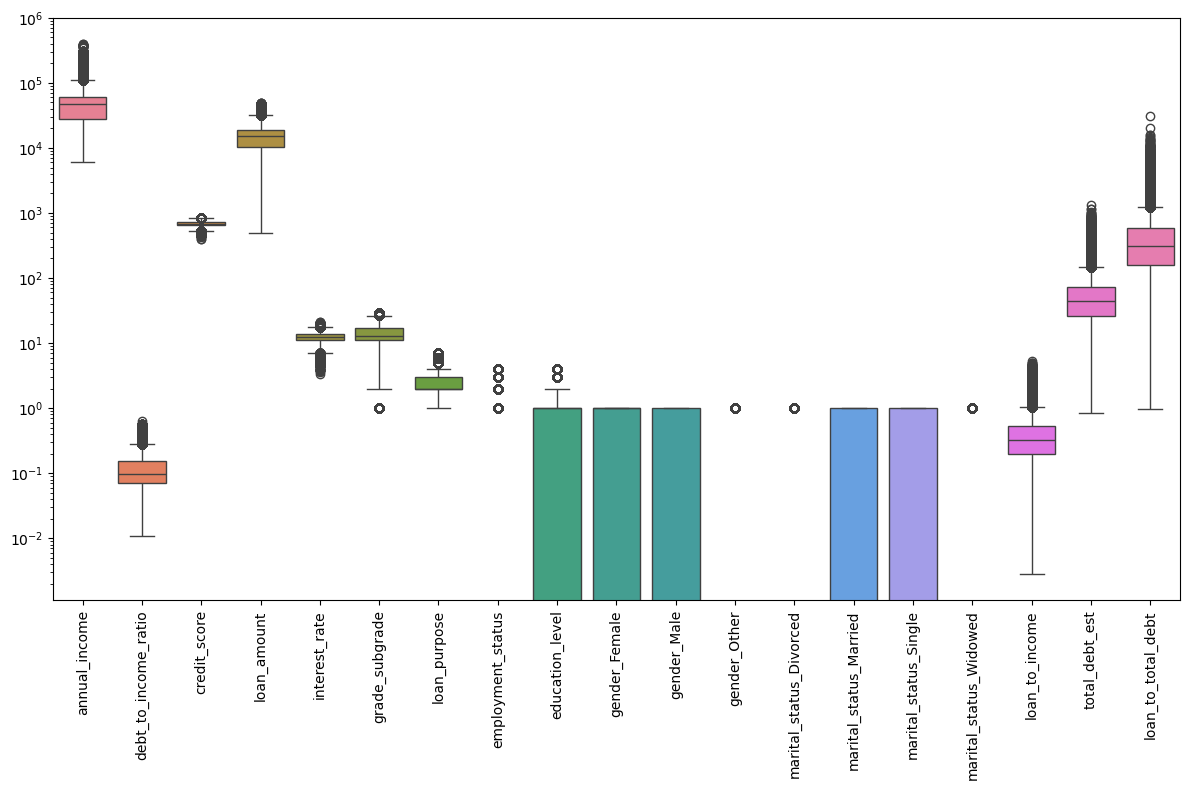

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
ax = sns.boxplot(data=df_train)

ax.set_yscale('log')   # escala log no eixo y

plt.xticks(rotation=90)
plt.title('')
plt.tight_layout()
plt.show()


# EDA

In [7]:
df_train.isna().sum()

annual_income              0
debt_to_income_ratio       0
credit_score               0
loan_amount                0
interest_rate              0
grade_subgrade             0
loan_purpose               0
employment_status          0
education_level            0
gender_Female              0
gender_Male                0
gender_Other               0
marital_status_Divorced    0
marital_status_Married     0
marital_status_Single      0
marital_status_Widowed     0
loan_to_income             0
total_debt_est             0
loan_to_total_debt         0
dtype: int64

In [8]:
df_train.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,grade_subgrade,loan_purpose,employment_status,education_level,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,loan_to_income,total_debt_est,loan_to_total_debt
count,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000
mean,48207.471032,0.120667,680.949791,15021.937942,12.357039,13.965073,2.610082,0.684544,0.831684,0.514995,0.478776,0.006229,0.035846,0.466409,0.486647,0.011099,0.427807,58.181427,473.252200
std,26700.214901,0.068535,55.409807,6933.189795,2.008837,5.114906,1.657732,1.331604,0.973053,0.499776,0.499550,0.078678,0.185907,0.498871,0.499822,0.104764,0.366755,49.783341,543.667280
min,6002.430000,0.011000,395.000000,500.090000,3.320000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002835,0.841754,0.970604
25%,27920.690000,0.072000,646.000000,10279.440000,10.990000,11.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.194614,25.920516,160.064415
50%,46603.520000,0.096000,682.000000,15000.220000,12.370000,13.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.322355,44.107119,311.677483
75%,60981.320000,0.156000,719.000000,18865.645000,13.680000,17.000000,3.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.537334,73.838621,582.935837
max,393381.740000,0.627000,849.000000,48954.700000,20.990000,29.000000,7.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.361253,1338.169664,30409.986616


# Target plot

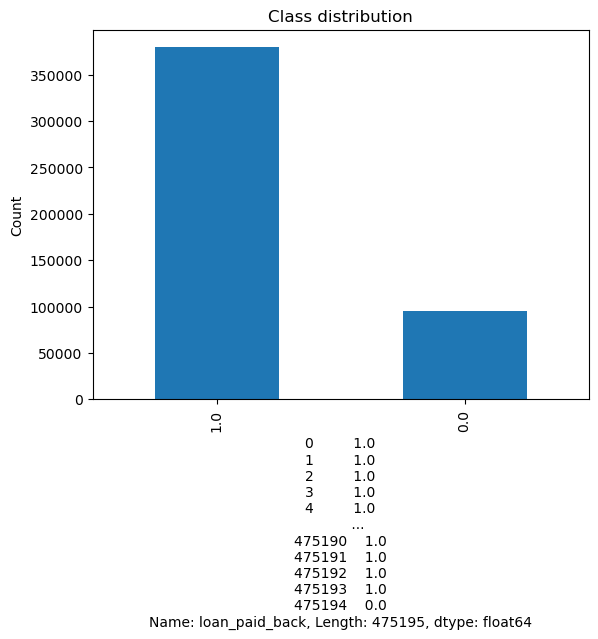

In [9]:
import matplotlib.pyplot as plt

y_train.value_counts().plot(kind="bar")
plt.xlabel(y_train)
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()


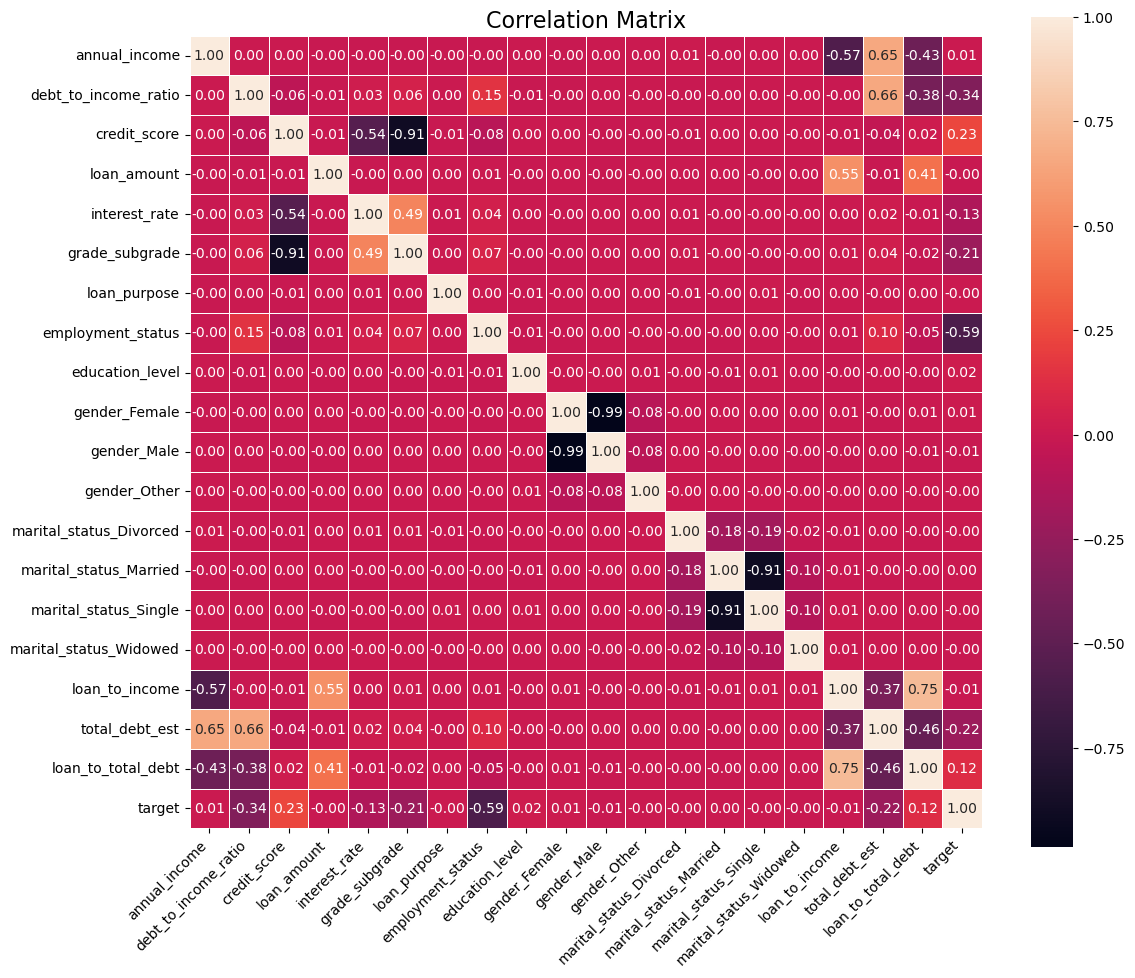

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd   # only if not imported yet

# Combine X and y into one DataFrame
df_corr = pd.concat(
    [df_train, y_train.rename("target")],  # rename target column if needed
    axis=1
)

# Correlation matrix (numeric columns only)
corr = df_corr.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [11]:
from sklearn.metrics import mutual_info_score

def mutual_info_loan_paid_back(series):
    return mutual_info_score(series,df_corr.target)

mi = df_corr.apply(mutual_info_loan_paid_back)
mi.sort_values(ascending=False)

C:\Users\emahc\anaconda4\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\emahc\anaconda4\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\emahc\anaconda4\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\emahc\anaconda4\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\ema

target                     5.018199e-01
loan_to_total_debt         5.018082e-01
loan_to_income             5.004306e-01
total_debt_est             4.692042e-01
employment_status          1.759167e-01
annual_income              1.223210e-01
loan_amount                1.191959e-01
debt_to_income_ratio       7.969565e-02
credit_score               3.370546e-02
grade_subgrade             2.674850e-02
interest_rate              1.307710e-02
loan_purpose               3.245419e-04
education_level            3.113894e-04
gender_Female              2.630371e-05
gender_Male                2.602354e-05
marital_status_Widowed     3.203553e-06
marital_status_Married     2.963546e-07
marital_status_Divorced    1.713792e-07
gender_Other               3.498074e-08
marital_status_Single      1.418256e-10
dtype: float64

# UnderSampling

In [12]:
from imblearn.under_sampling import RandomUnderSampler

print("Class distribution BEFORE undersampling (train):")
print(y_train.value_counts())
print()

# 1) Descobrir classes
class_counts = y_train.value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

n_minority = class_counts[minority_class]

# 2) Escolher a razão desejada majority/minority
#    Exemplo: majority = 2x minority
majority_ratio = 2.5
n_majority_new = int(n_minority * majority_ratio)

print(f"Minority class ({minority_class}) count: {n_minority}")
print(f"Majority class ({majority_class}) new count (target): {n_majority_new}")
print()

# 3) Definir estratégia de undersampling
sampling_strategy = {
    majority_class: n_majority_new,
    minority_class: n_minority
}

rus = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

df_train_res, y_train_res = rus.fit_resample(df_train, y_train)

# 4) Sobrescrever os nomes originais
df_train_under_sample = df_train_res
y_train_under_sample  = y_train_res

print("Class distribution AFTER undersampling (train):")
print(y_train_under_sample.value_counts())

from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)

train_dict_under = df_train_under_sample.to_dict(orient='records')
X_train_under = dv.fit_transform(train_dict_under)

val_dict_under = df_val.to_dict(orient='records')
X_val_under = dv.transform(val_dict_under)


Class distribution BEFORE undersampling (train):
loan_paid_back
1.0    379669
0.0     95526
Name: count, dtype: int64

Minority class (0.0) count: 95526
Majority class (1.0) new count (target): 238815

Class distribution AFTER undersampling (train):
loan_paid_back
1.0    238815
0.0     95526
Name: count, dtype: int64


# Model training


In [13]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)


In [14]:
df_train

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,grade_subgrade,loan_purpose,employment_status,education_level,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,loan_to_income,total_debt_est,loan_to_total_debt
0,47868.15,0.070,773,28644.19,10.16,6.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.598398,33.507705,854.853806
1,35444.49,0.153,693,27775.31,16.14,14.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.783628,54.230070,512.175434
2,92914.49,0.140,715,30784.02,12.35,13.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.331316,130.080286,236.653998
3,43761.69,0.156,723,8181.09,10.13,13.0,6.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.186946,68.268236,119.837428
4,63671.48,0.149,675,17626.06,12.60,12.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.276828,94.870505,185.790724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475190,51957.35,0.086,681,12452.00,14.96,13.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.239658,44.683321,278.672208
475191,20264.17,0.160,652,18207.08,12.17,18.0,2.0,2.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.898486,32.422672,561.553947
475192,25609.70,0.053,664,1418.39,12.66,18.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.055385,13.573141,104.499754
475193,39711.94,0.262,638,9121.82,11.20,17.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.229700,104.045283,87.671634


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

C_values = [0.01, 0.1, 1, 10, 100]

print("Logistic Regression \n")

for C in C_values:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    model = LogisticRegression(max_iter=1000, C=C)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)

    print(f"C = {C}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print("-" * 40)


Logistic Regression – comparação de parâmetros

C = 0.01
  Accuracy : 0.8920
  Precision: 0.9058
  Recall   : 0.9650
  F1-score : 0.9345
----------------------------------------
C = 0.1
  Accuracy : 0.8919
  Precision: 0.9058
  Recall   : 0.9649
  F1-score : 0.9344
----------------------------------------
C = 1
  Accuracy : 0.8919
  Precision: 0.9059
  Recall   : 0.9649
  F1-score : 0.9344
----------------------------------------
C = 10
  Accuracy : 0.8919
  Precision: 0.9059
  Recall   : 0.9649
  F1-score : 0.9344
----------------------------------------
C = 100
  Accuracy : 0.8919
  Precision: 0.9059
  Recall   : 0.9649
  F1-score : 0.9344
----------------------------------------


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



max_depth_values = [2, 4, 6, 8, 10, 20]   # None = sem limite de profundidade

print("Decision Tree \n")

for md in max_depth_values:
    model = DecisionTreeClassifier(
        random_state=1,
        max_depth=md
        # podes adicionar mais, ex: min_samples_leaf=5
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)

    print(f"max_depth = {md}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print("-" * 40)


Decision Tree – comparação de parâmetros

max_depth = 2
  Accuracy : 0.8969
  Precision: 0.8976
  Recall   : 0.9829
  F1-score : 0.9383
----------------------------------------
max_depth = 4
  Accuracy : 0.8997
  Precision: 0.9028
  Recall   : 0.9798
  F1-score : 0.9397
----------------------------------------
max_depth = 6
  Accuracy : 0.9021
  Precision: 0.9046
  Recall   : 0.9808
  F1-score : 0.9411
----------------------------------------
max_depth = 8
  Accuracy : 0.9020
  Precision: 0.9034
  Recall   : 0.9821
  F1-score : 0.9411
----------------------------------------
max_depth = 10
  Accuracy : 0.9010
  Precision: 0.9027
  Recall   : 0.9818
  F1-score : 0.9406
----------------------------------------
max_depth = 20
  Accuracy : 0.8807
  Precision: 0.9084
  Recall   : 0.9459
  F1-score : 0.9268
----------------------------------------


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# 2) Fine tuning do Random Forest
n_estimators_values = [50, 100, 200]
max_depth_values    = [None, 5, 10, 20]   # None = sem limite

print("Random Forest  ")

for n in n_estimators_values:
    for md in max_depth_values:
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=md,
            random_state=1,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        acc  = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec  = recall_score(y_val, y_pred)
        f1   = f1_score(y_val, y_pred)

        print(f"n_estimators = {n}, max_depth = {md}")
        print(f"  Accuracy : {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall   : {rec:.4f}")
        print(f"  F1-score : {f1:.4f}")
        print("-" * 50)


Random Forest – grid simples de parâmetros 
n_estimators = 50, max_depth = None
  Accuracy : 0.9000
  Precision: 0.9065
  Recall   : 0.9752
  F1-score : 0.9396
--------------------------------------------------
n_estimators = 50, max_depth = 5
  Accuracy : 0.8998
  Precision: 0.8962
  Recall   : 0.9889
  F1-score : 0.9403
--------------------------------------------------
n_estimators = 50, max_depth = 10
  Accuracy : 0.9023
  Precision: 0.9019
  Recall   : 0.9848
  F1-score : 0.9415
--------------------------------------------------
n_estimators = 50, max_depth = 20
  Accuracy : 0.9009
  Precision: 0.9038
  Recall   : 0.9802
  F1-score : 0.9405
--------------------------------------------------
n_estimators = 100, max_depth = None
  Accuracy : 0.9006
  Precision: 0.9055
  Recall   : 0.9774
  F1-score : 0.9401
--------------------------------------------------
n_estimators = 100, max_depth = 5
  Accuracy : 0.8998
  Precision: 0.8956
  Recall   : 0.9898
  F1-score : 0.9403
-------------

# XGB underSample

In [18]:
from itertools import product
from sklearn.metrics import roc_auc_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# DMatrix (assumindo dv, X_train, X_val, y_train, y_val já definidos)
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train_under, label=y_train_under_sample, feature_names=features)
dval   = xgb.DMatrix(X_val_under,   label=y_val,   feature_names=features)

# Grades pequenas, só nos mais importantes
max_depth_list        = [3, 5, 7]
min_child_weight_list = [1, 5]
eta_list              = [0.01, 0.05, 0.1]

num_boost_round = 200  # valor fixo

# scores[(max_depth, min_child_weight)] -> DataFrame(num_iter, eta, val_auc, f1)
scores = {}
all_rows = []   # para ver top configs no fim

for md, mcw in product(max_depth_list, min_child_weight_list):
    rows = []
    for eta in eta_list:
        xgb_params = {
            "objective": "binary:logistic",
            "eval_metric": "auc",
            "eta": eta,
            "max_depth": md,
            "min_child_weight": mcw,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "seed": 1,
        }

        model = xgb.train(
            params=xgb_params,
            dtrain=dtrain,
            num_boost_round=num_boost_round
        )

        # Probabilidades no validation
        y_proba_val = model.predict(dval)

        # Métrica principal: AUC
        val_auc = roc_auc_score(y_val, y_proba_val)

        # F1 (com threshold 0.4, como tinhas antes)
        y_pred_val = (y_proba_val > 0.4).astype(int)
        f1 = f1_score(y_val, y_pred_val, zero_division=0)

        print(
            f"max_depth={md}, min_child_weight={mcw}, eta={eta}, "
            f"num_boost_round={num_boost_round}, val_auc={val_auc:.4f}, f1={f1:.4f}"
        )

        row = {
            "max_depth": md,
            "min_child_weight": mcw,
            "eta": eta,
            "num_iter": num_boost_round,
            "val_auc": val_auc,
            "f1": f1,
        }
        rows.append(row)
        all_rows.append(row)

    scores[(md, mcw)] = pd.DataFrame(rows)

# ---------------------------
# Top configurações por AUC (e mostrando F1)
# ---------------------------
results_df = pd.DataFrame(all_rows).sort_values(
    by=["val_auc", "f1"],
    ascending=False
)
print("\nTop 10 configs por AUC:\n")
print(results_df.head(10))


max_depth=3, min_child_weight=1, eta=0.01, num_boost_round=200, val_auc=0.9085, f1=0.9406
max_depth=3, min_child_weight=1, eta=0.05, num_boost_round=200, val_auc=0.9147, f1=0.9412
max_depth=3, min_child_weight=1, eta=0.1, num_boost_round=200, val_auc=0.9166, f1=0.9415
max_depth=3, min_child_weight=5, eta=0.01, num_boost_round=200, val_auc=0.9085, f1=0.9406
max_depth=3, min_child_weight=5, eta=0.05, num_boost_round=200, val_auc=0.9147, f1=0.9411
max_depth=3, min_child_weight=5, eta=0.1, num_boost_round=200, val_auc=0.9166, f1=0.9415
max_depth=5, min_child_weight=1, eta=0.01, num_boost_round=200, val_auc=0.9115, f1=0.9411
max_depth=5, min_child_weight=1, eta=0.05, num_boost_round=200, val_auc=0.9175, f1=0.9420
max_depth=5, min_child_weight=1, eta=0.1, num_boost_round=200, val_auc=0.9192, f1=0.9423
max_depth=5, min_child_weight=5, eta=0.01, num_boost_round=200, val_auc=0.9115, f1=0.9411
max_depth=5, min_child_weight=5, eta=0.05, num_boost_round=200, val_auc=0.9174, f1=0.9418
max_depth=5, 

# XGB 

In [19]:
from itertools import product
from sklearn.metrics import roc_auc_score, f1_score
import pandas as pd
import xgboost as xgb
import json

# DMatrix (assuming dv, X_train, X_val, y_train, y_val are already defined)
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=features)

# Small grids, only on the most important params
max_depth_list        = [3, 5, 7]
min_child_weight_list = [1, 5]
eta_list              = [0.01, 0.05, 0.1]

num_boost_round = 200  # fixed value

# scores[(max_depth, min_child_weight)] -> DataFrame(num_iter, eta, val_auc, f1)
scores = {}
all_rows = []   # to inspect top configs at the end

# To store the best model
best_auc   = -1
best_f1    = -1
best_model = None
best_cfg   = None  # dict with params and metrics

for md, mcw in product(max_depth_list, min_child_weight_list):
    rows = []
    for eta in eta_list:
        xgb_params = {
            "objective": "binary:logistic",
            "eval_metric": "auc",
            "eta": eta,
            "max_depth": md,
            "min_child_weight": mcw,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "seed": 1,
        }

        model = xgb.train(
            params=xgb_params,
            dtrain=dtrain,
            num_boost_round=num_boost_round
        )

        # Probabilities on validation set
        y_proba_val = model.predict(dval)

        # Main metric: AUC
        val_auc = roc_auc_score(y_val, y_proba_val)

        # F1 (using threshold 0.8 here)
        y_pred_val = (y_proba_val > 0.5).astype(int)
        f1 = f1_score(y_val, y_pred_val, zero_division=0)

        print(
            f"max_depth={md}, min_child_weight={mcw}, eta={eta}, "
            f"num_boost_round={num_boost_round}, val_auc={val_auc:.4f}, f1={f1:.4f}"
        )

        # Row now has all params + num_boost_round + metrics
        row = {
            **xgb_params,                 # all XGBoost parameters
            "num_boost_round": num_boost_round,
            "val_auc": float(val_auc),
            "f1": float(f1),
        }
        rows.append(row)
        all_rows.append(row)

        # Update best model (prioritize AUC, break ties with F1)
        if (val_auc > best_auc) or (val_auc == best_auc and f1 > best_f1):
            best_auc = val_auc
            best_f1 = f1
            best_model = model
            best_cfg = row.copy()  # includes params + metrics

    scores[(md, mcw)] = pd.DataFrame(rows)

# ---------------------------
# Top configurations by AUC (showing F1 too)
# ---------------------------
results_df = pd.DataFrame(all_rows).sort_values(
    by=["val_auc", "f1"],
    ascending=False
)
print("\nTop 10 configs by AUC:\n")
print(results_df.head(10))


print("\nBest configuration found:\n", best_cfg)

# ---------------------------
# Save best model config
# ---------------------------
if best_model is not None:
    with open("xgb_best_params.json", "w") as f:
        json.dump(best_cfg, f, indent=2)
    print("Best configuration saved to 'xgb_best_params.json'")
else:
    print("No model was trained (something went wrong).")


max_depth=3, min_child_weight=1, eta=0.01, num_boost_round=200, val_auc=0.9085, f1=0.9406
max_depth=3, min_child_weight=1, eta=0.05, num_boost_round=200, val_auc=0.9146, f1=0.9413
max_depth=3, min_child_weight=1, eta=0.1, num_boost_round=200, val_auc=0.9167, f1=0.9414
max_depth=3, min_child_weight=5, eta=0.01, num_boost_round=200, val_auc=0.9085, f1=0.9406
max_depth=3, min_child_weight=5, eta=0.05, num_boost_round=200, val_auc=0.9146, f1=0.9414
max_depth=3, min_child_weight=5, eta=0.1, num_boost_round=200, val_auc=0.9167, f1=0.9415
max_depth=5, min_child_weight=1, eta=0.01, num_boost_round=200, val_auc=0.9114, f1=0.9410
max_depth=5, min_child_weight=1, eta=0.05, num_boost_round=200, val_auc=0.9174, f1=0.9417
max_depth=5, min_child_weight=1, eta=0.1, num_boost_round=200, val_auc=0.9190, f1=0.9422
max_depth=5, min_child_weight=5, eta=0.01, num_boost_round=200, val_auc=0.9114, f1=0.9410
max_depth=5, min_child_weight=5, eta=0.05, num_boost_round=200, val_auc=0.9174, f1=0.9416
max_depth=5, 